# MAQT Prototypes with FROZEN Features: BoT-IoT
## Capped Sample (3000) | ~11800 Train | Batch Size 64
## 50 Epochs (Early Stopping with Patience = 5) | LR 0.05
## Target (y) = "label_multiclass" | Data Reupload = 2

## Setup

In [1]:
import pennylane as qp
from pennylane import numpy as np
import torch

import matplotlib.pyplot as plt
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import json
from pathlib import Path
import time

In [2]:
from scripts.constants import (
    DEFAULT_EPOCHS, DEFAULT_LR, DEFAULT_BATCH_SIZE,
    DEFAULT_LAMBDA1, DEFAULT_LAMBDA2, DEFAULT_NOISE_RATE,
    BARREN_PLATEAU_VAR_THRESHOLD, DEFAULT_N_TRIALS, DEFAULT_PATIENCE,
)
from scripts.data import (
    class_balance_table,
    capped_sample,
    stratified_head,
    plot_class_balance_bars,
    plot_class_balance_pie,
    greedy_kcenter_sample,
    greedy_dpp_sample,
    plot_dataset_and_sampling_analysis,
    load_split,
    to_angles,
)
from scripts.circuit import build_forward_circuit, create_quantum_device
from scripts.train import train_maqt
from scripts.utils import get_torch_device, to_np_y
from scripts.logging import write_history_log
from scripts.memory import is_oom_error, run_batched_safely, safe_empty_cache
from scripts.prototypes import prototype_summary
from scripts.gradient import gradient_variance_probe
from scripts.theory import verify_fidelity_convention

In [3]:
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available?: {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"CUDA device name: {torch.cuda.get_device_name(0)}")
    print(f"Current CUDA device index: {torch.cuda.current_device()}")

PyTorch version: 2.12.1+cu126
CUDA available?: True
CUDA device name: NVIDIA GeForce GTX 1060
Current CUDA device index: 0


## Config

In [4]:
NOTEBOOK_NAME = "23.maqt-FROZEN-feat-prototypes_bot-iot-more-train"

dataset = "BoT-IoT"
target_col = "label_multiclass"
data_path = f"data/FROZEN/{dataset}"
frozen_feat_path = "team-artifacts/teamC_week3_FROZEN_handoff.json"

SEED = 42

In [5]:
check = verify_fidelity_convention(dim=4, n_trials=30, seed=SEED)
print("Fidelity-convention self-check PASSED:", check)

Fidelity-convention self-check PASSED: {'max_pairwise_disagreement': 0.0, 'max_fvg_violation': 0.0}


## Load Team C's FROZEN Features

In [6]:
handoff = json.loads(Path(frozen_feat_path).read_text())
FEATURE_COLS = list(handoff["frozen_subsets"][dataset]["features"])
print(f"Team C selector: {handoff['frozen_subsets'][dataset]['selector']}")
print(f"k={len(FEATURE_COLS)} features: {FEATURE_COLS}")

Team C selector: QIGPSO
k=10 features: ['n_pkts_total', 'n_bytes_total', 'src_bytes', 'rate', 'pkt_size_min', 'pkt_size_max', 'pkt_size_mean', 'pkt_size_std', 'protocol', 'conn_state']


## Load Team A's FROZEN Dataset

In [7]:
# load all data
X_train_full, y_train_full, class_names, df_train = load_split(
    data_path, f"train", target_col, csv=True, selected_cols=FEATURE_COLS, return_df=True
)
X_cal_full, y_cal_full, _, df_cal = load_split(
    data_path, f"calibration", target_col, csv=True, selected_cols=FEATURE_COLS, return_df=True
)
X_test_full, y_test_full, _, df_test = load_split(
    data_path, f"test", target_col, csv=True, selected_cols=FEATURE_COLS, return_df=True
)
X_zero_full, y_zero_full, _, df_zero = load_split(
    data_path, f"zeroday", target_col, csv=True, selected_cols=FEATURE_COLS, return_df = True
)

# check shape
print(f"train   : {X_train_full.shape, y_train_full.shape}\n\
cal     : {X_cal_full.shape, y_cal_full.shape}\n\
test    : {X_test_full.shape, y_test_full.shape}\n\
zero    : {X_zero_full.shape, y_zero_full.shape}\n\
classes : {class_names}\n"
)

df_train.head(3)

train   : ((148729, 10), (148729,))
cal     : ((18591, 10), (18591,))
test    : ((18591, 10), (18591,))
zero    : ((683, 10), (683,))
classes : ['DDoS', 'DoS', 'Normal', 'Reconnaissance']



,n_pkts_total,n_bytes_total,src_bytes,rate,pkt_size_min,pkt_size_max,pkt_size_mean,pkt_size_std,protocol,conn_state,label_multiclass
0,-0.262256,-0.798644,-0.774964,-0.356930,0.000000,0.123458,-0.266091,0.827772,0.0,0.0,DoS
1,0.427561,-0.121016,0.000000,-0.123704,0.000000,0.120431,0.030826,0.766490,0.0,0.0,DoS
2,0.768961,0.200956,0.368220,1.725276,0.761987,0.244690,0.422755,0.618673,0.0,0.0,DDoS


## EDA (Before Preprocessing)

number of classes: 4


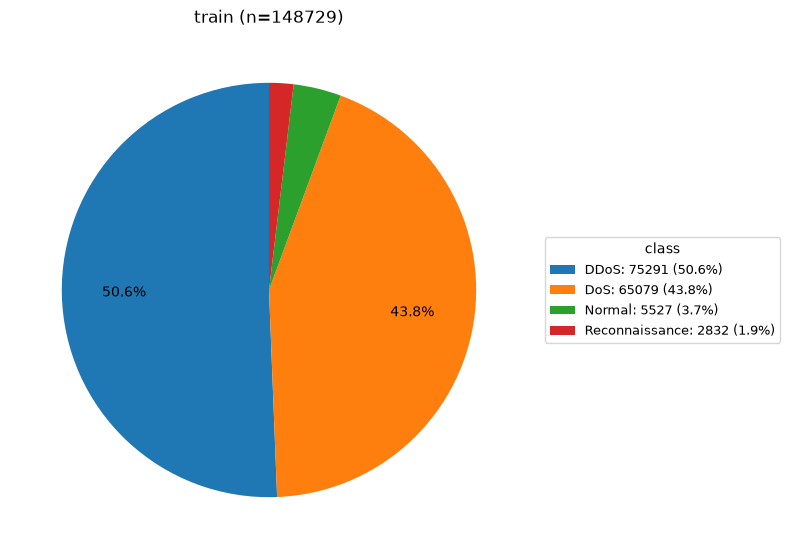

In [8]:
num_classes = len(class_names)
print(f"number of classes: {num_classes}")

# pie chart
fig, ax = plt.subplots(figsize=(8, 8))

plot_class_balance_pie(
    y_train_full, class_names,
    title=f"train (n={len(to_np_y(y_train_full))})",
    ax=ax,
)

plt.tight_layout()
plt.show()

## Scaling

In [9]:
# fit scaler on full train (raw); transform elsewhere via to_angles()
scaler = StandardScaler()
X_train_full_scaled = scaler.fit_transform(X_train_full)
print(f"scaled full train: {X_train_full_scaled.shape}")

scaled full train: (148729, 10)


## PCA (Optional)

In [10]:
USE_PCA = True   # set to False to skip PCA
TARGET_VARIANCE = 0.95

features (raw dim): 10
explained_variance_ratio_: [0.3698 0.2823 0.1538 0.0927 0.0827 0.0085 0.0052 0.0034 0.0008 0.0007]
cumulative:                [0.3698 0.6521 0.8059 0.8986 0.9813 0.9898 0.995  0.9985 0.9993 1.    ]
first 1 PCs keep 36.98% variance
first 2 PCs keep 65.21% variance
first 3 PCs keep 80.59% variance
first 4 PCs keep 89.86% variance
first 5 PCs keep 98.13% variance
first 6 PCs keep 98.98% variance
first 7 PCs keep 99.50% variance
first 8 PCs keep 99.85% variance
first 9 PCs keep 99.93% variance
first 10 PCs keep 100.00% variance
components needed for >=95.0% variance: 5


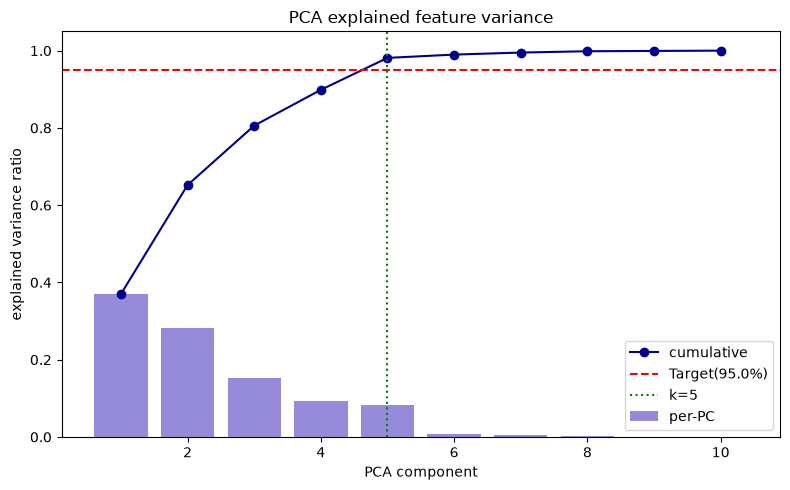

feature dim for angles: 5 | USE_PCA=True


In [11]:
if USE_PCA:
    pca_full = PCA(random_state=SEED).fit(X_train_full_scaled)
    ratios = pca_full.explained_variance_ratio_
    cum = np.cumsum(ratios)
    n_feat = len(ratios)

    print(f"features (raw dim): {n_feat}")
    print("explained_variance_ratio_:", np.round(ratios, 4))
    print("cumulative:               ", np.round(cum, 4))
    for k in range(1, n_feat + 1):
        print(f"first {k} PCs keep {cum[k - 1]*100:.2f}% variance")

    # smallest k with >= target variance
    k95 = int(np.searchsorted(cum, TARGET_VARIANCE) + 1)
    k95 = min(k95, len(cum))  # safety
    print(f"components needed for >={TARGET_VARIANCE*100}% variance: {k95}")

    fig, ax = plt.subplots(1, 1, figsize=(8, 5))
    ax.bar(range(1, n_feat + 1), ratios, color="slateblue", alpha=0.7, label="per-PC")
    ax.plot(range(1, n_feat + 1), cum, marker="o", color="darkblue", label="cumulative")
    ax.axhline(TARGET_VARIANCE, color="red", linestyle="--", label=f"Target({TARGET_VARIANCE*100}%)")
    ax.axvline(k95, color="green", linestyle=":", label=f"k={k95}")
    ax.set_xlabel("PCA component")
    ax.set_ylabel("explained variance ratio")
    ax.set_title("PCA explained feature variance")
    ax.legend()
    plt.tight_layout()
    plt.show()

    pca = PCA(n_components=k95, random_state=SEED)
    X_train_full_feat = pca.fit_transform(X_train_full_scaled)
else:
    pca = None
    k95 = X_train_full_scaled.shape[1]
    X_train_full_feat = X_train_full_scaled

# angle bounds from full train feature space (pca or scaled)
x_min, x_max = X_train_full_feat.min(0), X_train_full_feat.max(0)
print(f"feature dim for angles: {X_train_full_feat.shape[1]} | USE_PCA={USE_PCA}")

## Data Subset (Optional)

In [12]:
SUBSET = True   # set to False for the full dataset
PER_CLASS_CAP = 10000

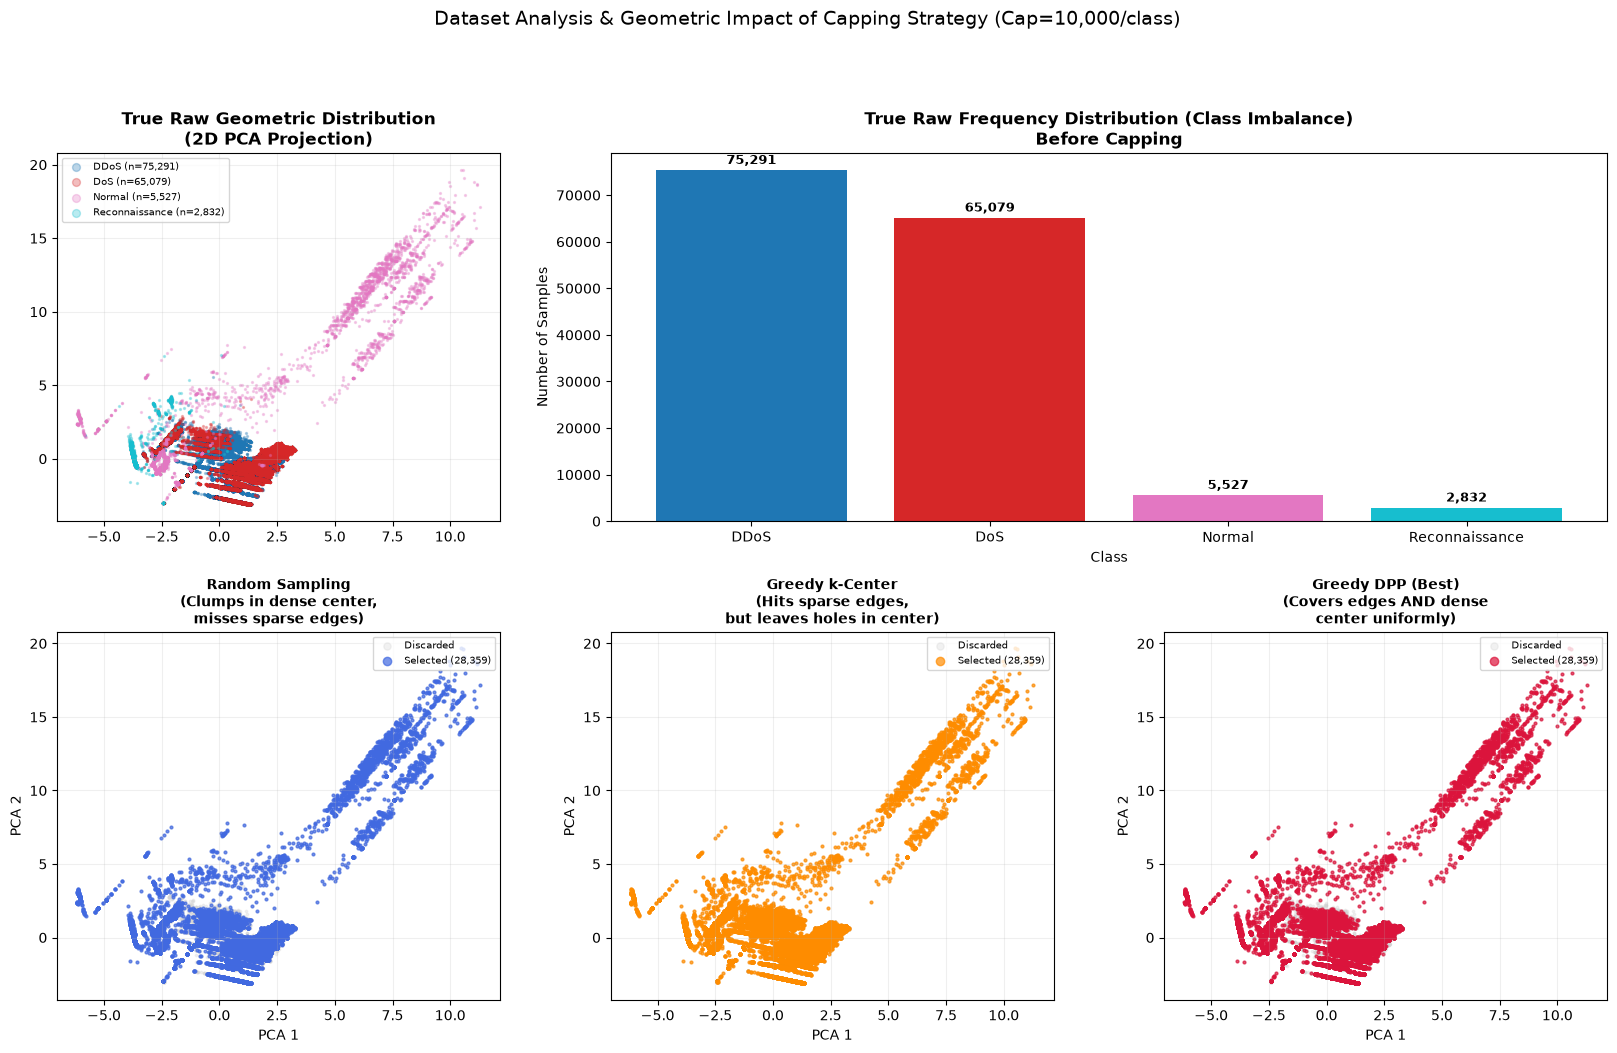


Running representative DPP coreset sampling (cap=10000)...
Coreset selected: 28359 samples.
train raw: ((28359, 10), (28359,)) | SUBSET=True | cap=10000


In [13]:
# compare sampling strategies on RAW full train, then apply DPP coreset
if SUBSET:
    plot_dataset_and_sampling_analysis(
        X_train_full,
        y_train_full,
        per_class_cap=PER_CLASS_CAP,
        class_names=class_names,
        seed=SEED,
    )

    print(f"\nRunning representative DPP coreset sampling (cap={PER_CLASS_CAP})...")
    X_train, y_train = greedy_dpp_sample(
        X_train_full, y_train_full, per_class_cap=PER_CLASS_CAP, seed=SEED
    )
    print(f"Coreset selected: {X_train.shape[0]} samples.")
else:
    X_train, y_train = X_train_full, y_train_full
    print(f"using full train (no subset): {X_train.shape[0]} samples")

print(f"train raw: {X_train.shape, y_train.shape} | SUBSET={SUBSET} | cap={PER_CLASS_CAP if SUBSET else 'all'}")

## EDA (After Preprocessing)

number of classes: 4


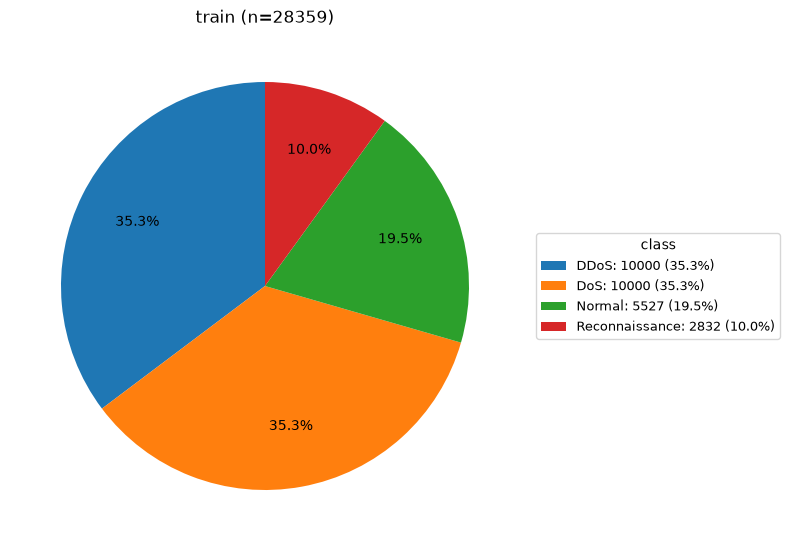

In [14]:
num_classes = len(class_names)
print(f"number of classes: {num_classes}")

# pie chart
fig, ax = plt.subplots(figsize=(8, 8))

plot_class_balance_pie(
    y_train, class_names,
    title=f"train (n={len(to_np_y(y_train))})",
    ax=ax,
)

plt.tight_layout()
plt.show()

## Mapping Features $\rightarrow$ [0, $\pi$]

angles: (28359, 5) | USE_PCA=True | SUBSET=True


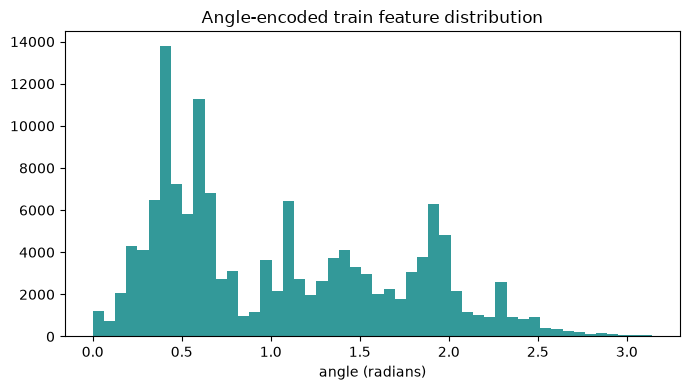

In [15]:
# raw -> scale -> optional pca -> [0, pi] using bounds from full train
X_train_angles_all = to_angles(
    X_train, scaler, x_min, x_max, pca=pca if USE_PCA else None, angle_max=np.pi
)

# seeded stratified holdout from train for early stopping (cal/test untouched)
VAL_FRAC = 0.1
_y_all = y_train
idx = np.arange(len(X_train_angles_all))
idx_fit, idx_val = train_test_split(
    idx, test_size=VAL_FRAC, stratify=_y_all, random_state=SEED,
)
X_train_angles, y_train = X_train_angles_all[idx_fit], _y_all[idx_fit]
X_val_angles, y_val = X_train_angles_all[idx_val], _y_all[idx_val]
print(
    f"angles fit: {X_train_angles.shape} | val: {X_val_angles.shape} | "
    f"VAL_FRAC={VAL_FRAC} | USE_PCA={USE_PCA} | SUBSET={SUBSET}"
)

fig, ax1 = plt.subplots(1, 1, figsize=(7, 4))
ax1.hist(X_train_angles.flatten(), bins=50, color="teal", alpha=0.8)
ax1.set_xlabel("angle (radians)")
ax1.set_title("Angle-encoded train (fit) feature distribution")
plt.tight_layout()
plt.show()


## Quantum Circuit: Angle Encoding, Data Reuploading, and Adding Noise

$x\xrightarrow[\text{encode}]{\phi(x)}\ket{\psi(x)}\xrightarrow[\text{variational}]{U(\theta)}\ket{\Phi(x)}\xrightarrow{\Lambda_p}\rho(x)$
- $x$: classical data
- $\phi(x)$: `qp.AngleEmbedding()`
- $\ket{\psi(x)}$: quantum state after encoding
- $U(\theta)$: `qp.StronglyEntanglingLayers()`
- $\ket{\Phi(x)}$: quantum state after variational transform
- $\rho(x)=\Lambda_p(\ket{\Phi(x)}\bra{\Phi(x)})$: standard depolarization channel to model NISQ noise

In [16]:
num_qubits = int(k95)           # pca comps if USE_PCA; else scaled feature dim
num_layers = 2                  # reupload same classical data
noise_rate = DEFAULT_NOISE_RATE
print(f"num_qubits={num_qubits} (USE_PCA={USE_PCA})")

num_qubits=5 (USE_PCA=True)


In [17]:
# initialize devices
device = get_torch_device()
dev = create_quantum_device(num_qubits) # or dev = qp.device("default.mixed", wires=num_qubits)

# define circuit
forward_circuit = build_forward_circuit(dev, num_qubits, num_layers, noise_rate=noise_rate)

## Gradient Variance Probe

pre-train grad var = 1.19e-08 (thr=1e-06)


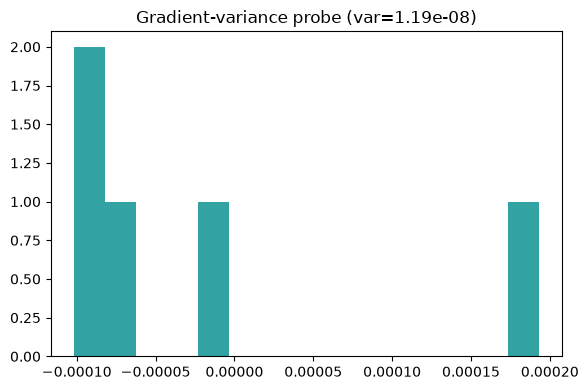

In [18]:
barren_plateau_var = BARREN_PLATEAU_VAR_THRESHOLD
n_trials = 5

safe_empty_cache()

# probe on CPU (recommended)
x_probe = X_train_angles[:1]

try:
    grad_var, grad_samples = gradient_variance_probe(
        forward_circuit, x_probe, num_qubits, num_layers,
        n_trials=n_trials,
        device=torch.device("cpu"),
    )

    print(f"pre-train grad var = {grad_var:.2e} (thr={barren_plateau_var:.0e})")
    if grad_var < barren_plateau_var:
        print("warning: possible barren plateau architecture")

    plt.figure(figsize=(6, 4)); plt.hist(grad_samples, bins=15, color="darkcyan", alpha=0.8)
    plt.title(f"Gradient-variance probe (var={grad_var:.2e})"); plt.tight_layout(); plt.show()

except RuntimeError as e:
    if is_oom_error(e):
        print("\t[OOM] barren-plateau probe skipped (non-critical diagnostic).")
        safe_empty_cache()
    else:
        raise

## Training

$$
L = L_{CE} + \lambda_1*L_{intra} + \lambda_2*L_{inter}
$$

Minimizing:
- $L_{CE}$ adjusts $\theta$ for better class predictions.
- $L_{intra}$ pulls each sample toward its class prototype
- $L_{inter}$ pushs different-class prototypes apart (maximize trace distance)

In [20]:
epochs = 50
batch_size = 64
lr = DEFAULT_LR
lambda1 = 0.5
lambda2 = 0.02
early_stopping = True
patience = 5
min_delta = 0.001

out_dir = Path("models/prototypes") / dataset
out_dir.mkdir(parents=True, exist_ok=True)

ckpt_dir = out_dir / f"{NOTEBOOK_NAME}_seed{SEED}"
latest_ckpt = ckpt_dir / "maqt-latest.pt"
resume_from = latest_ckpt if latest_ckpt.exists() else None

print(f"checkpoint_dir: {ckpt_dir}")
print(f"resume_from: {resume_from}")

checkpoint_dir: models/prototypes/BoT-IoT/23.maqt-FROZEN-feat-prototypes_bot-iot-more-train_seed42
resume_from: None


In [ ]:
torch.manual_seed(SEED)

result = run_batched_safely(
    train_maqt,
    X_train_angles,
    y_train,
    n_classes=num_classes,
    n_qubits=num_qubits,
    n_layers=num_layers,
    forward_circuit=forward_circuit,
    device=device,
    epochs=epochs,
    lr=lr,
    batch_size=batch_size,
    min_batch=2,
    label="train_maqt",
    lambda1_max=lambda1,
    lambda2_max=lambda2,
    use_weighted_sampler=True,
    seed=SEED,
    early_stopping=early_stopping,
    patience=patience,
    min_delta=min_delta,
    X_val=X_val_angles,
    y_val=y_val,
    checkpoint_dir=ckpt_dir,
    save_every_epoch=True,
    resume_from=resume_from,
    reset_early_stopping_on_resume=True,
    heartbeat_every_steps=20,  # pass None to less verbose
    notebook_name=NOTEBOOK_NAME,
    log_dir=ckpt_dir,
)

if result is None:
    raise RuntimeError("train_maqt failed even at min_batch (OOM)")

theta, head, prototypes, ema_protos, history = result
theta_star = theta
classifier_head = head
safe_empty_cache()
print(
    "\n"
    f"epochs_ran={history.get('epochs_ran')} | "
    f"best_epoch={history.get('best_epoch')} | "
    f"stopped_early={history.get('stopped_early')} | "
    f"stop_reason={history.get('stop_reason')}"
)

	epoch 1 step 20 (5%) loss=0.9799 elapsed=11s eta=241s
	epoch 1 step 40 (9%) loss=0.8097 elapsed=23s eta=230s
	epoch 1 step 60 (14%) loss=0.7874 elapsed=34s eta=219s
	epoch 1 step 80 (18%) loss=0.7308 elapsed=46s eta=208s
	epoch 1 step 100 (23%) loss=0.7055 elapsed=57s eta=196s
	epoch 1 step 120 (27%) loss=0.6745 elapsed=68s eta=184s
	epoch 1 step 140 (32%) loss=0.6046 elapsed=80s eta=172s
	epoch 1 step 160 (36%) loss=0.5628 elapsed=91s eta=161s
	epoch 1 step 180 (41%) loss=0.6724 elapsed=102s eta=149s
	epoch 1 step 200 (45%) loss=0.5608 elapsed=113s eta=138s
	epoch 1 step 220 (50%) loss=0.5426 elapsed=125s eta=127s
	epoch 1 step 240 (54%) loss=0.6031 elapsed=136s eta=115s
	epoch 1 step 260 (59%) loss=0.5398 elapsed=147s eta=104s
	epoch 1 step 280 (63%) loss=0.4940 elapsed=159s eta=92s
	epoch 1 step 300 (68%) loss=0.5110 elapsed=170s eta=81s
	epoch 1 step 320 (72%) loss=0.6942 elapsed=181s eta=70s
	epoch 1 step 340 (77%) loss=0.6277 elapsed=193s eta=58s
	epoch 1 step 360 (81%) loss=0.5

## Prototypes

In [ ]:
proto_df = pd.DataFrame(prototype_summary(prototypes, class_names))
proto_df

In [ ]:
# save prototypes (all-in-one checkpoint)
out_dir = Path("models/prototypes") / dataset
out_dir.mkdir(parents=True, exist_ok=True)

ckpt_path = out_dir / f"{NOTEBOOK_NAME}-checkpoint.pt"
torch.save(
    {
        "theta": theta_star.detach().cpu(),
        "head_state_dict": head.state_dict(),
        "prototypes": {k: v.detach().cpu() for k, v in prototypes.items()},

        # rebuild / inference meta
        "class_names": list(class_names),
        "num_classes": num_classes,
        "num_qubits": num_qubits,
        "num_layers": num_layers,
        "noise_rate": noise_rate,

        # FROZEN feature + angle pipeline (must match train)
        "feature_cols": list(FEATURE_COLS),
        "teamC_handoff": frozen_feat_path,
        "data_path": data_path,
        "target_col": target_col,
        "use_pca": bool(USE_PCA),
        "subset": bool(SUBSET),
        "per_class_cap": int(PER_CLASS_CAP) if SUBSET else None,
        "sampler": "greedy_dpp" if SUBSET else None,
        "scaler": scaler,                    # StandardScaler fitted on full train
        "pca": pca,                          # PCA fitted on scaled full train (or None)
        "k95": int(k95),
        "angle_x_min": np.asarray(x_min),    # on pca space if USE_PCA else scaled space
        "angle_x_max": np.asarray(x_max),
        "angle_min": 0.0,
        "angle_max": float(np.pi),
    },
    ckpt_path,
)
print("published:", ckpt_path.resolve())

## Visualization

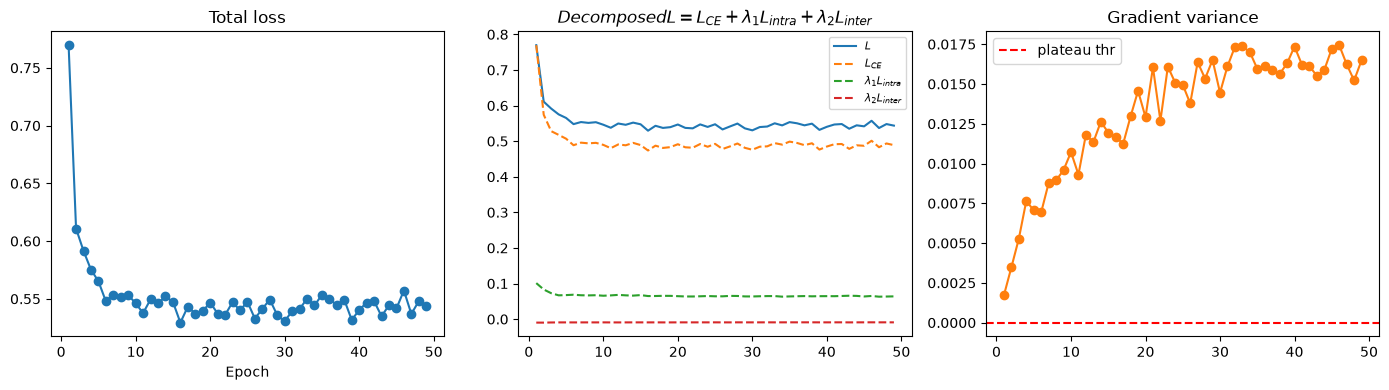

In [23]:
# plots
epochs_x = range(1, len(history["loss"]) + 1)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# total loss
axes[0].plot(epochs_x, history["loss"], marker="o")
axes[0].set_title("Total loss")
axes[0].set_xlabel("Epoch")

# decomposed (weighted like the objective)
axes[1].plot(epochs_x, history["loss"], marker=None, label=r"$L$")
axes[1].plot(epochs_x, history["L_CE"], "--", label=r"$L_{CE}$")
axes[1].plot(epochs_x, [lambda1 * v for v in history["L_intra"]], "--", label=r"$\lambda_1 L_{intra}$")
axes[1].plot(epochs_x, [lambda2 * v for v in history["L_inter"]], "--", label=r"$\lambda_2 L_{inter}$")
axes[1].set_title(r"$Decomposed L = L_{CE}+\lambda_1 L_{intra}+\lambda_2 L_{inter}$")
axes[1].legend(fontsize=8)

# grad var
axes[2].plot(epochs_x, history["grad_var"], marker="o", color="tab:orange")
axes[2].axhline(1e-6, color="red", linestyle="--", label="plateau thr")  # or BARREN_PLATEAU_VAR_THRESHOLD
axes[2].set_title("Gradient variance")
axes[2].legend()

plt.tight_layout()
plt.show()

## Logging

In [24]:
# write log (final)
log_path = write_history_log(
    history,
    NOTEBOOK_NAME,
    extra={
        ## data
        "teamC_handoff": frozen_feat_path,
        "data_path": data_path,
        "dataset": dataset,
        "feature_cols": FEATURE_COLS,
        "target_col": target_col,
        "n_train": len(X_train),
        "class_names": list(class_names),
        "use_pca": bool(USE_PCA),
        "subset": bool(SUBSET),
        "per_class_cap": int(PER_CLASS_CAP) if SUBSET else None,
        "sampler": "greedy_dpp" if SUBSET else None,
        "num_qubits": num_qubits,
        "k95": int(k95),

        # algo 1: MAQT train
        "epochs": epochs,
        "batch_size": batch_size,
        "lr": lr,
        "lambda1": lambda1,
        "lambda2": lambda2,

        ## quantum model
        "noise_rate": noise_rate,
        "num_layers": num_layers,
        "num_classes": num_classes,

        ## training
        "train_total_sec": float(sum(history["epoch_sec"])) if history.get("epoch_sec") else None,
        "loss_last": float(history["loss"][-1]) if history["loss"] else None,
        "barren_plateau_var": barren_plateau_var,
        "barren_plateau_any": bool(
            any(g < barren_plateau_var for g in history["grad_var"])
        ) if history.get("grad_var") else None,
        "seed": SEED,
        "early_stopping": early_stopping,
        "patience": patience,
        "best_epoch": history.get("best_epoch"),
        "best_score": history.get("best_score"),
        "stopped_early": history.get("stopped_early"),
        "epochs_ran": history.get("epochs_ran"),
        "stop_reason": history.get("stop_reason"),
        "interrupted": history.get("interrupted"),
        "checkpoint_dir": str(ckpt_dir),
    },
    log_dir="logs",
)
print(f"wrote {log_path.resolve()}")

wrote /home/lawun330/Desktop/quantum-sentinel/logs/23.maqt-FROZEN-feat-prototypes_bot-iot.log
